# Example of using fuctions from package tools

Set up the path for the execution.

In [1]:
import sys
import os
import pandas as pd

# Define the absolute path of the directory
home_dir = r'D:\Storage\ETH\Thesis\Code'
lib_dir = os.path.join(home_dir, 'EMIP-Toolkit') 
tools_dir = os.path.join(home_dir, 'Playground')
sys.path.append(tools_dir)
sys.path.append(lib_dir)

from emtk import parsers, visualization, util, aoi

Parse the data.

In [2]:
from tools import path_similarity

# Parse corrected EMIP data - now directly returns a DataFrame ready for build_vector
eye_events = path_similarity.auxiliary.parse_corrected_emip_data(lib_dir)

print(eye_events.head())

Parsed corrected EMIP data for 159 participants.
Prepared data for build_vector with 61799 rows.
   Sequence            code_file        code_language   timestamp  duration  \
0         0  rectangle_java2.jpg  rectangle_java2.jpg  3678763539      64.0   
1         1  rectangle_java2.jpg  rectangle_java2.jpg  3679003436      92.0   
2         2  rectangle_java2.jpg  rectangle_java2.jpg  3679099463      92.0   
3         3  rectangle_java2.jpg  rectangle_java2.jpg  3679211458      64.0   
4         4  rectangle_java2.jpg  rectangle_java2.jpg  3679455448      76.0   

           x0          y0  aoi_x  aoi_y  aoi_width  aoi_height      token  \
0  809.586875  357.589375    809    370         10          15          =   
1  678.156957  232.652609    660    225         47          15      class   
2  668.989565  233.655652    660    225         47          15      class   
3  655.791875  239.992500    660    225         47          15      class   
4  750.404211  228.840000    717    225    

Specify the experiment and trial we want to analyze for the scanpath

In [3]:
# exp = ('experiment_id', 'trial_id')

exp_a = ('135', '2')
exp_b = ('196', '2')

Use the python library multimatch_gaze to compute path similarity.\
We use 2 random generated scan-path as baseline to normalize the final value.\ 

final_value = original_value - base_line.

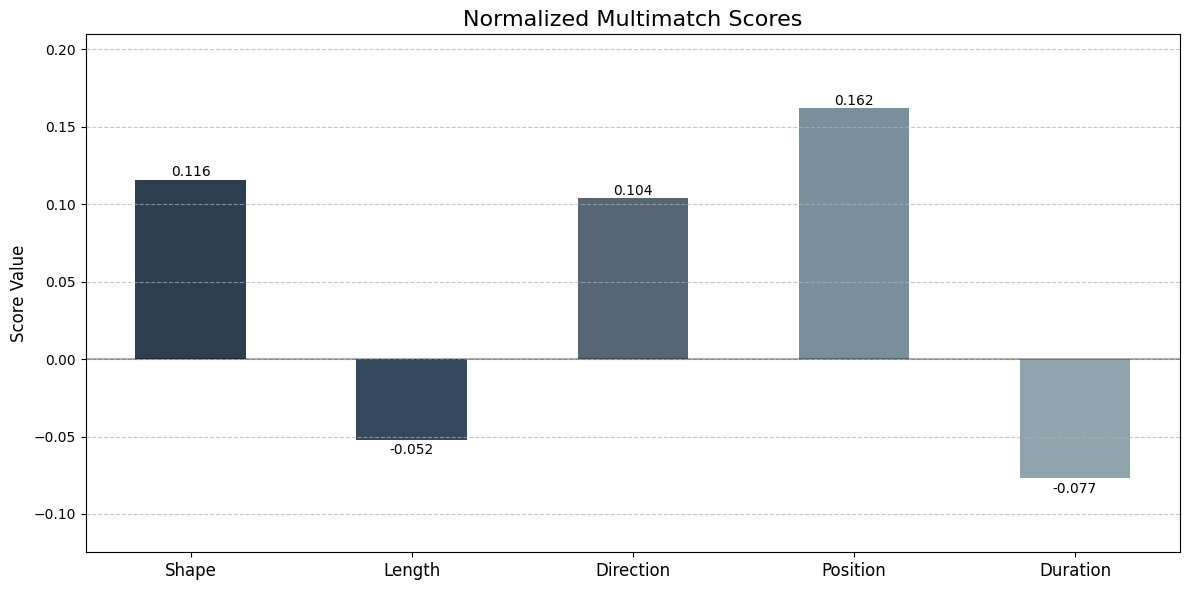

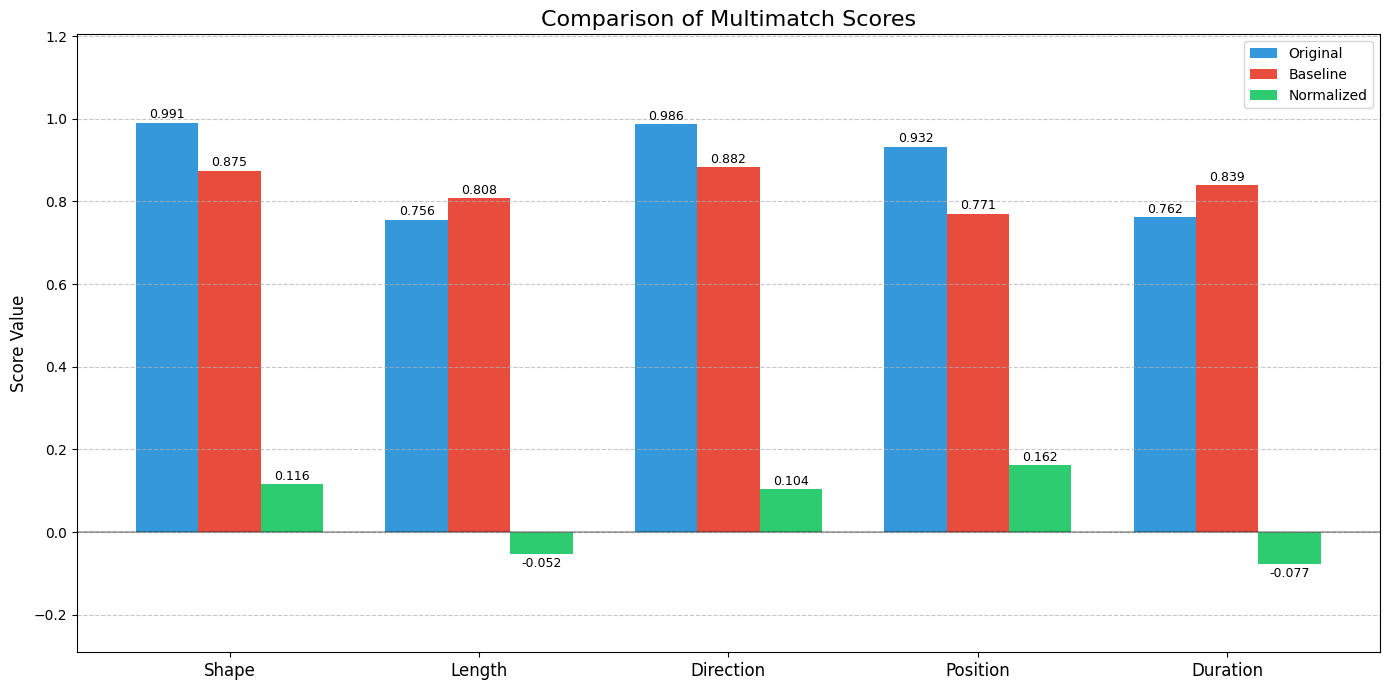

In [4]:
from tools import path_similarity
import matplotlib.pyplot as plt

scores = path_similarity.multimatch(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events
)

path_similarity.auxiliary.visualize_multimatch_scores(scores, "Normalized Multimatch Scores")
plt.show()

path_similarity.auxiliary.visualize_all_scores(scores)
plt.show()

Compute path similarity by using scasim (part of ScanDL)

In [5]:
# parameter normalize can be 'durations', 'fixations' or 'None'
# It actually compute Scan path difference
result = path_similarity.scasim(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    normalize = 'duration'
)

print("Scasim score:", result)

Scasim score: 0.8245013082597275


Compute NLD for both scanpath

In [ ]:
distance, nld = path_similarity.nld_for_original(exp_a, exp_b, eye_events)

print(f"Distance: {distance}, NLD: {nld}")

KeyError: 'eye_tracker'